<a href="https://colab.research.google.com/github/l-yunxi/optimisation-multiclass-regression/blob/main/homework_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Homework Project

In [1]:
import numpy as np
from scipy.special import logsumexp
import matplotlib.pyplot as plt
import time

### Question 1

In [ ]:
np.random.seed(42)  # the answer to everything obviously

d, m, k = 1000, 1000, 50

# A is our data matrix
A = np.random.randn(m, d)

#print(A.shape)
print(A[:3, :3])

[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.39935544  0.92463368  0.05963037]
 [-0.67517827 -0.14451867 -0.79241992]]


### Question 2

In [ ]:
# generate matrix X and E
# E is noise
# X is our parameter/weights matrix
X = np.random.randn(d, k)
E = np.random.randn(m, k)

print(X.shape)

Y = A @ X + E

#index of the maximum value in each row - this is the class label
b = np.argmax(Y, axis = 1)


(1000, 50)


### Loss Function

In [2]:
# loss function

def compute_loss(x, A, b, m):
  scores = A @ x
  c_score = scores[np.arange(m), b] # take the correct score for the class
  log_a = logsumexp(scores, axis = 1) # compute log... for every row/object
  per_ob = -c_score + log_a   # cross-entropy loss per object
  return np.sum(per_ob)

### Partial Deriv Function

In [3]:
# partial derivative of loss fn

def partial_deriv(x, A, m, b, k):
  scores = A @ x
  scores -= np.max(scores, axis = 1, keepdims = True) # I did it to avoid overflow
  exp_s = np.exp(scores)
  sumexp_s = np.sum(exp_s, axis = 1, keepdims=True)
  soft_max = exp_s / sumexp_s # probability the given example is in the right class
  I = np.zeros((m, k))
  I[np.arange(m), b] = 1.0 # indicator function as a matrix
  err_matrix = I - soft_max
  samples_sum = A.T @ err_matrix # summing all samples i while weighting by their feature
  return -1 * samples_sum

#print(partial_deriv(X)) - synthetic data
#print(partial_deriv(X_init, A_train, m1, b_train, k1))


### Gradient Descent Code

In [ ]:
# implementing gradient descent

start_point = np.zeros((d, k))
learn_rate = 0.01    # I changed learning rate to the optimal for now - from 0.1 to 0.01
iterations = 100
tolerance = 1e-2 # 0.01

# lipshitz for gradient descent, but doesn't work properly yet, need to be adjusted
#L_gd = np.linalg.norm(A, ord = 2)**2
#learn_rate = 1 / L_gd

def grad_descent(start_point, learn_rate, iterations, tol):
    x = start_point
    prev_loss = float('inf')

    for i in range(iterations):
        x = x - learn_rate * partial_deriv(x, A, m, b, k)  # update step
        cur_loss = float(compute_loss(x, A, b, m))
        print(f"Iteration {i+1}: compute_loss(x) = {float(cur_loss):.4f}")

    # stopping condition
        #print(f"{abs(cur_loss - prev_loss): .6f}")
        if abs(cur_loss - prev_loss) < tol:
            print(f"Converged at: {i + 1}")
            break

        prev_loss = cur_loss

    return x

print(grad_descent(start_point, learn_rate, iterations, tolerance).shape)

Iteration 1: compute_loss(x) = 7.6851
Iteration 2: compute_loss(x) = 5.3133
Iteration 3: compute_loss(x) = 4.6644
Iteration 4: compute_loss(x) = 4.2325
Iteration 5: compute_loss(x) = 3.9104
Iteration 6: compute_loss(x) = 3.6550
Iteration 7: compute_loss(x) = 3.4446
Iteration 8: compute_loss(x) = 3.2665
Iteration 9: compute_loss(x) = 3.1126
Iteration 10: compute_loss(x) = 2.9777
Iteration 11: compute_loss(x) = 2.8579
Iteration 12: compute_loss(x) = 2.7504
Iteration 13: compute_loss(x) = 2.6532
Iteration 14: compute_loss(x) = 2.5647
Iteration 15: compute_loss(x) = 2.4835
Iteration 16: compute_loss(x) = 2.4087
Iteration 17: compute_loss(x) = 2.3395
Iteration 18: compute_loss(x) = 2.2752
Iteration 19: compute_loss(x) = 2.2152
Iteration 20: compute_loss(x) = 2.1591
Iteration 21: compute_loss(x) = 2.1064
Iteration 22: compute_loss(x) = 2.0567
Iteration 23: compute_loss(x) = 2.0099
Iteration 24: compute_loss(x) = 1.9656
Iteration 25: compute_loss(x) = 1.9237
Iteration 26: compute_loss(x) = 1.

### Partial Deriv with Caching

In [30]:
# partial derivative with caching

def partial_deriv_bcgd(scores, A, m, k, b):
  scores -= np.max(scores, axis = 1, keepdims = True) # I did it to avoid overflow
  exp_s = np.exp(scores)
  sumexp_s = np.sum(exp_s, axis = 1, keepdims=True)
  soft_max = exp_s / sumexp_s
  I = np.zeros((m, k))
  I[np.arange(m), b] = 1.0
  err_matrix = I - soft_max
  samples_sum = A.T @ err_matrix
  return -1 * samples_sum

### BCGD Loss Function

In [31]:
def compute_loss_bcgd(scores, b, m):
  c_score = scores[np.arange(m), b] # take the correct score for the class
  log_a = logsumexp(scores, axis = 1) # compute log... for every row/object
  per_ob = -c_score + log_a   # cross-entropy loss per object
  return np.sum(per_ob) # loss for all

### BCGD

In [ ]:
 # implementing block coordinate descent (BCD) with Gauss–Southwell rule

#learn_rate2 = 0.05
it2 = 20000
tol2 = 1e-4
start_point2 = np.zeros((d, k))


#print(start_point2.sum())

def bcgd(st_point, it, tol):
    x = st_point.copy()
    scores = A @ x
    prev_loss = float('inf')
    eta = 1.7

    for i in range(it):
      #if (it % 1500 == 0):
      #  eta *= 0.8
      grad = partial_deriv_bcgd(scores)
      j = np.argmax(np.linalg.norm(grad, axis=1))
      # print(f"Upd row:{j}, block_size {grad[j].shape}")

      L_j = np.linalg.norm(A[:,j]) **2 # L_i

      step = eta / L_j * grad[j]  # α_i * f = (1/L_i) * grad
      #step = lr * grad[j]
      x[j] -= step  # y_i = y_{i-1} - α_i * grad
      scores -= np.outer(A[:,j], step)

      cur_loss = float(compute_loss_bcgd(scores))
      print(f"Iteration {i+1}: compute_loss(x) = {float(cur_loss):.4f}")

      # stopping condition
      #print(f"{abs(cur_loss - prev_loss): .6f}")
      if abs(cur_loss - prev_loss) < tol:
        print(f"Converged at: {i + 1}")
        break

      prev_loss = cur_loss
    return x

print(bcgd(start_point2, it2, tol2).shape)


TypeError: partial_deriv_bcgd() missing 4 required positional arguments: 'A', 'm', 'k', and 'b'

### Importing Data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/forest-cover-type-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.2M/11.2M [00:00<00:00, 42.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/uciml/forest-cover-type-dataset/versions/1


In [ ]:
!pip install scikit-learn

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [5]:
import gdown

id = '1vRgxjLpGQlmX1S8z8LeB8HnMWkC5KwIl'
gdown.download(f'https://drive.google.com/uc?id={id}', 'covtype.csv')


Downloading...
From: https://drive.google.com/uc?id=1vRgxjLpGQlmX1S8z8LeB8HnMWkC5KwIl
To: /content/covtype.csv
100%|██████████| 75.2M/75.2M [00:00<00:00, 107MB/s]


'covtype.csv'

In [6]:
# importing the data

df = pd.read_csv('covtype.csv')
df = df.fillna(0)                 # filled empty rows with 0's
df = df[df['Cover_Type'] != 0]    # only considering cover-type labels that are not 0
#print(df['Cover_Type'].unique()) # was used to ensure each cover-type label was unique
#df.isnull().sum()                # was used to see if there are any empty cells

### Cleaning Data

In [7]:
   # shuffle rows and convert into matrix

res = df.sample(frac=1).reset_index(drop=True)
A1 = res.drop(columns=['Cover_Type']).values
b1 = res['Cover_Type'].values # our classes


   # split data - train, val and test sets (80 - 10 - 10)

#for A1
split_1 = int(0.8 * len(A1))
A_train = A1[:split_1]                 # training - A
A_val_test = A1[split_1:]

split_2 = int(0.5 * len(A_val_test))
A_val = A_val_test[:split_2]           # validation - A
A_test = A_val_test[split_2:]          # test - A

#for b1
b_train = b1[:split_1]                 # training - B
b_val_test = b1[split_1:]

split_2b = int(0.5 * len(b_val_test))
b_val = b_val_test[:split_2b]          # validation - B
b_test = b_val_test[split_2b:]         # test - B

   # scale the training set and transform val and test set

scaler = StandardScaler()

#for A1
scal_A_train = scaler.fit_transform(A_train)  # scales and transforms
trans_A_val   = scaler.transform(A_val)       # only transforms
trans_A_test  = scaler.transform(A_test)      # only transforms

#trans_A_val, A_val, b_val

###Checking data splitting

In [ ]:
print(b_train.shape)
print(b_val.shape)
print(b_test.shape)
print(b1.shape)


(464809,)
(58101,)
(58102,)
(581012,)


In [ ]:
print(A_train.shape)
print(A_val.shape)
print(A_test.shape)
print(A1.shape)

(464809, 54)
(58101, 54)
(58102, 54)
(581012, 54)


### Test on a real data

In [21]:
# to change indexes of the labels from 1..7 to 0..6
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
b_train = le.fit_transform(b_train)
b_test = le.fit_transform(b_test)
b_val = le.fit_transform(b_val)


#print(b_train.dtype)
#np.unique(b_train)

In [9]:
# making new X matrix (d1, k1)
np.random.seed(13)
d1 = scal_A_train.shape[1]
k1 = len(np.unique(b_train))
m1 = len(scal_A_train)
X_init = np.zeros((d1, k1))

# check if all objects have labels
print(np.sum(b_train == -1))
len(b_train) == len(A_train)

0


True

In [ ]:
print(compute_loss(X_init, A_train, b_train, m1))

904476.5504722501


In [ ]:
print((partial_deriv(X_init, A_train, m1, b_train, k1))[:3,:3])
print((partial_deriv(X_init, scal_A_train, m1, b_train, k1))[:3,:3])

[[-3.33826398e+08 -4.64960781e+08  1.27887301e+08]
 [-1.61040893e+07 -2.40947263e+07  5.28622671e+06]
 [-1.28869571e+06 -2.13335371e+06  3.42851286e+05]]
[[-102423.19352778   30998.44926139   57736.53625441]
 [   -546.84661443    7223.60769079   -5249.28325495]
 [  22156.32606718   16649.01062365  -25320.99196774]]


### Real Data Gradient Descent

In [10]:
# implementing gradient descent - scaled

start_point = X_init
learn_rate = 1e-6
iterations = 3000
tol = 23

def gd_scaled(st_point, lr, it, tol, test_set):
  global X_GD_checkpoint

  #lists
  gd_time = []
  gd_iter = []
  gd_loss = []
  gd_acc = []

  #time
  start_time = time.time()

  #initial X param matrix
  x = start_point.copy()

  #initializing prev_loss so initial loss diff always > tol
  prev_loss = float('inf')

  #iterating and updating param matrix via training
  for i in range(it):
      x = x - lr * partial_deriv(x, scal_A_train, m1, b_train, k1)  # calling partial_deriv fn
      cur_loss = float(compute_loss(x, scal_A_train, b_train, m1))  # calling compute_loss fn
      print(f"Iteration {i+1}: compute_loss(x) = {float(cur_loss):.4f}")

    #accuracy and time stamp saving points
      if (i + 1) % 100 == 0: #if iter mult of 100 / 10 to test
        scores = test_set @ x
        pred = np.argmax(scores, axis = 1)
        acc = np.mean(pred == b_test)
        elapsed_time = time.time() - start_time
        gd_time.append(elapsed_time)
        gd_iter.append(i+1)
        gd_loss.append(cur_loss)
        gd_acc.append(float(acc))


    #stopping condition
      if abs(cur_loss - prev_loss) < tol:
          print(f"Converged at: {i + 1}")
          break

      prev_loss = cur_loss

  return x, gd_time, gd_iter, gd_loss, gd_acc

In [ ]:
gd_scaled(start_point, learn_rate, iterations, tol, trans_A_test)

Iteration 1: compute_loss(x) = 842457.4195
Iteration 2: compute_loss(x) = 797980.0592
Iteration 3: compute_loss(x) = 764678.0349
Iteration 4: compute_loss(x) = 738514.4464
Iteration 5: compute_loss(x) = 717182.8737
Iteration 6: compute_loss(x) = 699312.8305
Iteration 7: compute_loss(x) = 684026.9561
Iteration 8: compute_loss(x) = 670731.4802
Iteration 9: compute_loss(x) = 659008.8871
Iteration 10: compute_loss(x) = 648556.6451
Iteration 11: compute_loss(x) = 639149.7123
Iteration 12: compute_loss(x) = 630616.6824
Iteration 13: compute_loss(x) = 622824.2062
Iteration 14: compute_loss(x) = 615666.5790
Iteration 15: compute_loss(x) = 609058.6229
Iteration 16: compute_loss(x) = 602930.7098
Iteration 17: compute_loss(x) = 597225.2053
Iteration 18: compute_loss(x) = 591893.8767
Iteration 19: compute_loss(x) = 586895.9680
Iteration 20: compute_loss(x) = 582196.7454
Iteration 21: compute_loss(x) = 577766.3823
Iteration 22: compute_loss(x) = 573579.0912
Iteration 23: compute_loss(x) = 569612.44

(array([[ 1.72249886e+00, -9.80844121e-01, -4.56287430e-01,
         -1.25674049e-01, -1.92125044e-01, -3.42899434e-01,
          3.75331219e-01],
        [-4.58312160e-02, -4.53961684e-02,  3.44521598e-02,
          2.50977476e-03,  3.85115344e-02,  5.79138709e-03,
          9.96252840e-03],
        [-1.51510931e-01,  6.78088845e-02,  1.07621045e-01,
         -2.60818304e-03,  3.62807520e-02, -5.18280178e-02,
         -5.76354954e-03],
        [-1.97564305e-01,  2.39107574e-01,  7.03690066e-02,
          9.04881643e-03, -1.42341310e-02, -3.73887988e-02,
         -6.93381626e-02],
        [-1.21816088e-01, -2.97839055e-02,  6.40975194e-02,
          2.38017398e-02,  5.99511185e-02, -2.33719866e-02,
          2.71216029e-02],
        [-4.74559599e-02,  7.61243811e-02,  1.01137299e-04,
          3.92517669e-02, -1.13138842e-01, -1.22953115e-04,
          4.52404692e-02],
        [-1.49241883e-01,  1.21353665e-01, -2.11734765e-02,
          3.32342277e-02,  5.29068844e-02, -7.09074898e-02

### Accuracy Computing + Testing - GD

In [22]:
def predict(x, A):
  scores = A @ x
  return np.argmax(scores, axis=1)

predictions = predict(X_GD_test1, trans_A_val)
accuracy = np.mean(predictions == b_val)
print(f"Accuracy: {accuracy:.4f}")

#trans_A_val, A_val, b_val

Accuracy: 0.7159


In [11]:
X_GD_test1, gd_time1, gf_iter1, gd_loss1, gd_acc1 = gd_scaled(start_point, learn_rate, iterations, tol, trans_A_test)

Iteration 1: compute_loss(x) = 842556.9950
Iteration 2: compute_loss(x) = 798160.0234
Iteration 3: compute_loss(x) = 764916.3722
Iteration 4: compute_loss(x) = 738792.1561
Iteration 5: compute_loss(x) = 717485.9333
Iteration 6: compute_loss(x) = 699631.3276
Iteration 7: compute_loss(x) = 684353.8571
Iteration 8: compute_loss(x) = 671061.6821
Iteration 9: compute_loss(x) = 659338.5811
Iteration 10: compute_loss(x) = 648882.9080
Iteration 11: compute_loss(x) = 639470.2488
Iteration 12: compute_loss(x) = 630929.6625
Iteration 13: compute_loss(x) = 623128.1589
Iteration 14: compute_loss(x) = 615960.3212
Iteration 15: compute_loss(x) = 609341.2075
Iteration 16: compute_loss(x) = 603201.3862
Iteration 17: compute_loss(x) = 597483.3874
Iteration 18: compute_loss(x) = 592139.1169
Iteration 19: compute_loss(x) = 587127.9349
Iteration 20: compute_loss(x) = 582415.2052
Iteration 21: compute_loss(x) = 577971.1828
Iteration 22: compute_loss(x) = 573770.1486
Iteration 23: compute_loss(x) = 569789.72

In [ ]:
X_GD_baseline, gd_time_bl, gd_iter_bl, gd_loss_bl, gd_acc_bl = gd_scaled(start_point, learn_rate, iterations, tol, trans_A_test)

Iteration 1: compute_loss(x) = 842457.4195
Iteration 2: compute_loss(x) = 797980.0592
Iteration 3: compute_loss(x) = 764678.0349
Iteration 4: compute_loss(x) = 738514.4464
Iteration 5: compute_loss(x) = 717182.8737
Iteration 6: compute_loss(x) = 699312.8305
Iteration 7: compute_loss(x) = 684026.9561
Iteration 8: compute_loss(x) = 670731.4802
Iteration 9: compute_loss(x) = 659008.8871
Iteration 10: compute_loss(x) = 648556.6451
Iteration 11: compute_loss(x) = 639149.7123
Iteration 12: compute_loss(x) = 630616.6824
Iteration 13: compute_loss(x) = 622824.2062
Iteration 14: compute_loss(x) = 615666.5790
Iteration 15: compute_loss(x) = 609058.6229
Iteration 16: compute_loss(x) = 602930.7098
Iteration 17: compute_loss(x) = 597225.2053
Iteration 18: compute_loss(x) = 591893.8767
Iteration 19: compute_loss(x) = 586895.9680
Iteration 20: compute_loss(x) = 582196.7454
Iteration 21: compute_loss(x) = 577766.3823
Iteration 22: compute_loss(x) = 573579.0912
Iteration 23: compute_loss(x) = 569612.44

### Real Data BCGD

In [40]:
it2 = 3000
# 23 between 1e-5 and 1e-4
tol2 = 23  # 5 that corresponds to 1e-5, because we have sum
start_point2 = np.zeros((d1, k1))
#learn_rate = 1e-6

def bcgd(st_point, it, tol, A, b):
    global X_checkpoint

    start = time.time()
    acc_bcgd = []
    times = []
    iteration = []
    loss = []

    x = st_point.copy()
    scores = A @ x

    prev_loss = float('inf')
    eta = 1.7

    for i in range(it):
     # if (it % 1500 == 0):
      #  eta *= 0.8

      grad = partial_deriv_bcgd(scores, scal_A_train, m1, k1, b_train)
      j = np.argmax(np.linalg.norm(grad, axis=1)) # take the highest gradient
      # print(f"Upd row:{j}, block_size {grad[j].shape}")

      L_j = np.linalg.norm(A[:,j])**2 # L_j - Lipschitz constant for block j

      step = eta / L_j * grad[j]  # α_j * f = (1/L_j) * grad
      #step = lr * grad[j]  # fixed stepsize
      x[j] -= step  # x_j = x[j-1] - α_j * grad
      scores -= np.outer(A[:,j], step) # A[:,j] * step

      cur_loss = float(compute_loss_bcgd(scores,b_train, m1))
      print(f"Iteration {i+1}: compute_loss(x) = {float(cur_loss):.4f}")

      # check accuracy + time + checkpoint
      if (i + 1) % 100 == 0:
        X_checkpoint = x.copy()  # in the case I want to stop the function earlier
        pred = np.argmax(scores, axis = 1)
        accuracy = np.mean(pred == b_train)
        #print(f"loss = {cur_loss}, acc = {accuracy}")
        acc_bcgd.append(accuracy)  # approximate
        time_bcgd = time.time() - start
        times.append(time_bcgd)
        iteration.append(i+1)
        loss.append(cur_loss)

      # stopping condition
      #print(f"{abs(cur_loss - prev_loss): .6f}")
      if abs(cur_loss - prev_loss) < tol:
        print(f"Converged at: {i + 1}")
        break

      prev_loss = cur_loss

    return x, acc_bcgd, times, iteration, loss

#### Computing time + prediction


In [41]:
X_BCGD, acc_bcgd, times, iteration_bcgd, loss = bcgd(start_point2, it2, tol2, scal_A_train, b_train)


Iteration 1: compute_loss(x) = 852411.8595
Iteration 2: compute_loss(x) = 820828.7923
Iteration 3: compute_loss(x) = 800001.7626
Iteration 4: compute_loss(x) = 781323.7386
Iteration 5: compute_loss(x) = 768900.2901
Iteration 6: compute_loss(x) = 757294.8003
Iteration 7: compute_loss(x) = 748155.5320
Iteration 8: compute_loss(x) = 740126.8269
Iteration 9: compute_loss(x) = 732298.5612
Iteration 10: compute_loss(x) = 725119.6902
Iteration 11: compute_loss(x) = 719233.4910
Iteration 12: compute_loss(x) = 712573.6412
Iteration 13: compute_loss(x) = 707148.4815
Iteration 14: compute_loss(x) = 700943.2271
Iteration 15: compute_loss(x) = 695003.0284
Iteration 16: compute_loss(x) = 689296.9695
Iteration 17: compute_loss(x) = 684327.5025
Iteration 18: compute_loss(x) = 679750.8124
Iteration 19: compute_loss(x) = 674261.4119
Iteration 20: compute_loss(x) = 668973.4921
Iteration 21: compute_loss(x) = 664224.6927
Iteration 22: compute_loss(x) = 659149.5700
Iteration 23: compute_loss(x) = 655041.84

In [37]:
X_BCGD2, acc_bcgd2, times2, iteration_bcgd2, loss2 = bcgd(start_point2, it2, tol2, scal_A_train, b_train)


Iteration 1: compute_loss(x) = 852411.8595
Iteration 2: compute_loss(x) = 820828.7923
Iteration 3: compute_loss(x) = 800001.7626
Iteration 4: compute_loss(x) = 781323.7386
Iteration 5: compute_loss(x) = 768900.2901
Iteration 6: compute_loss(x) = 757294.8003
Iteration 7: compute_loss(x) = 748155.5320
Iteration 8: compute_loss(x) = 740126.8269
Iteration 9: compute_loss(x) = 732298.5612
Iteration 10: compute_loss(x) = 725119.6902
Iteration 11: compute_loss(x) = 719233.4910
Iteration 12: compute_loss(x) = 712573.6412
Iteration 13: compute_loss(x) = 707148.4815
Iteration 14: compute_loss(x) = 700943.2271
Iteration 15: compute_loss(x) = 695003.0284
Iteration 16: compute_loss(x) = 689296.9695
Iteration 17: compute_loss(x) = 684327.5025
Iteration 18: compute_loss(x) = 679750.8124
Iteration 19: compute_loss(x) = 674261.4119
Iteration 20: compute_loss(x) = 668973.4921
Iteration 21: compute_loss(x) = 664224.6927
Iteration 22: compute_loss(x) = 659149.5700
Iteration 23: compute_loss(x) = 655041.84

KeyboardInterrupt: 

In [ ]:
X_BCGD3, acc_bcgd3, times3, iteration_bcgd3, loss3 = bcgd(start_point2, it2, tol2, scal_A_train, b_train, learn_rate)


In [38]:
def predict_BCGD(x, A):
  scores = A @ x
  return np.argmax(scores, axis=1)

In [39]:
# prediction with step 1/L
predictions_bcgd = predict_BCGD(X_checkpoint, trans_A_val)
accuracy_test = np.mean(predictions_bcgd == b_val)

print(accuracy_test)

0.7155814874098553


In [35]:
# prediction with step 1.7/L

predictions_bcgd2 = predict_BCGD(X_BCGD2, trans_A_val)
accuracy_val = np.mean(predictions_bcgd2 == b_val)

print(accuracy_val)

0.7125006454277896


In [ ]:
predictions_bcgd3 = predict_BCGD(X_checkpoint, trans_A_test)
accuracy_test3 = np.mean(predictions_bcgd3 == b_test)

print(accuracy_test3)

In [ ]:
print((partial_deriv(X_init, A_train, m1, b_train, k1))[:3,:3])
print((partial_deriv(X_init, scal_A_train, m1, b_train, k1))[:3,:3])

### TEST TIME PLOT


In [ ]:
# plot on 20000 iterations - BCGD
plt.plot(times, acc_bcgd, label = 'BCGD')
plt.xlabel('Time, s')
plt.ylabel('Accuracy')
plt.title('Accuracy vs CPU time')
plt.legend()

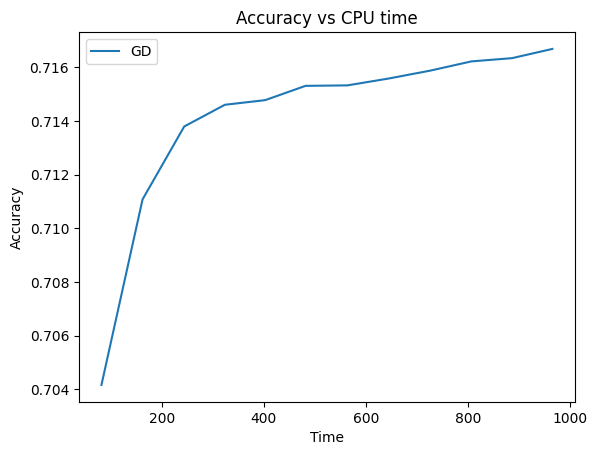

In [ ]:
# plot on 20000 iterations - GD test
plt.plot(gd_time_bl, gd_acc_bl, label = 'GD')
plt.xlabel('Time, s')
plt.ylabel('Accuracy')
plt.title('Accuracy vs CPU time')
plt.legend()

In [ ]:
# plot on 2000 iterations - GD
plt.plot(gd_time1, gd_acc1, label = 'GD')
plt.xlabel('Time, s')
plt.ylabel('Accuracy')
plt.title('Accuracy vs CPU time')
plt.legend()


#### Accuracy vs CPU time

In [ ]:
# add gradient descent line

plt.plot(times, acc_bcgd, label = 'BCGD_1/L')
plt.plot(times2, acc_bcgd2, label = 'BCGD_1.7/L')
plt.plot(times3, acc_bcgd3, label = 'BCGD_fixed')


plt.xlabel('Time, s')
plt.ylabel('Accuracy')
plt.title('Accuracy vs CPU time')
plt.legend()

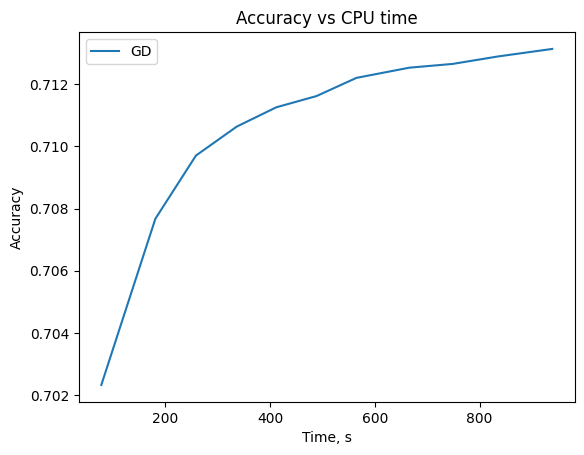

In [12]:
# GD_test
# X_GD_test1, gd_time1, gf_iter1, gd_loss1, gd_acc1

plt.plot(gd_time1, gd_acc1, label = 'GD')
plt.xlabel('Time, s')
plt.ylabel('Accuracy')
plt.title('Accuracy vs CPU time')
plt.legend()

#### Accuracy vs Iteration

In [ ]:
plt.plot(iteration_bcgd, acc_bcgd,  label = 'BCGD_1/L')
plt.plot(iteration_bcgd2, acc_bcgd2,  label = 'BCGD_1.7/L')
plt.plot(iteration_bcgd3, acc_bcgd3,  label = 'BCGD_fixed')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Iteration')
plt.legend()

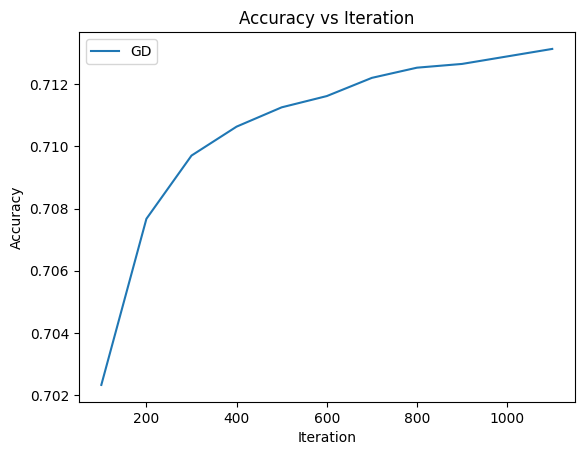

In [16]:
# GD - test

plt.plot(gf_iter1, gd_acc1, label = 'GD')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Iteration')
plt.legend()

#### Loss vs Iteration


In [ ]:
plt.plot(iteration_bcgd, loss, label = 'BCGD_1/L')
plt.plot(iteration_bcgd2, loss2, label = 'BCGD_1.7/L')
plt.plot(iteration_bcgd3, loss3, label = 'BCGD_fixed')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs Iteration')
plt.legend()

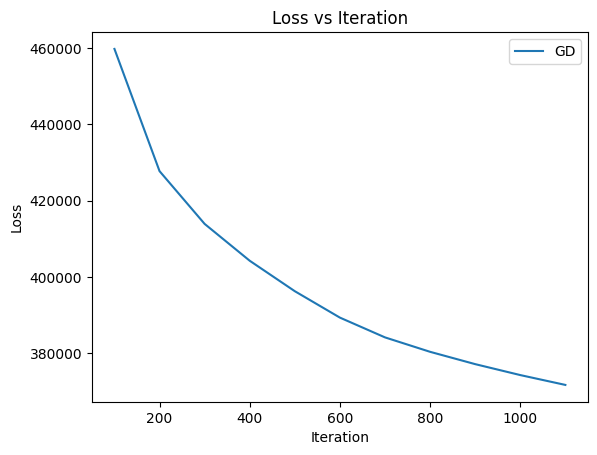

In [17]:
# loss vs iter - GD test
plt.plot(gf_iter1, gd_loss1, label = 'GD')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs Iteration')
plt.legend()

Iteration vs Time

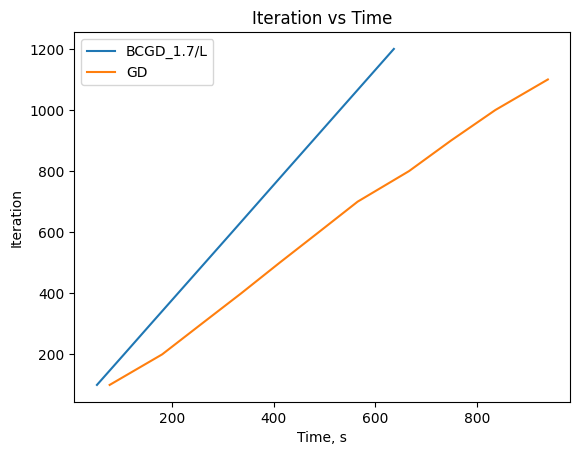

In [44]:
plt.plot(times, iteration_bcgd, label = 'BCGD_1.7/L')
plt.plot(gd_time1, gf_iter1, label = 'GD')

plt.xlabel('Time, s')
plt.ylabel('Iteration')
plt.title('Iteration vs Time')
plt.legend()

In [46]:
from collections import Counter

# Dummy classifier - predicts most frequent class
most_frequent_class = Counter(b_train).most_common(1)[0][0]
dummy_predictions = np.full(len(b_val), most_frequent_class)
dummy_accuracy = np.mean(dummy_predictions == b_val)
print(f"Dummy accuracy (most frequent class): {dummy_accuracy:.4f}")

# Random classifier
random_predictions = np.random.randint(0, 7, len(b_val))
random_accuracy = np.mean(random_predictions == b_val)
print(f"Random accuracy: {random_accuracy:.4f}")

print(f"Your model accuracy: 0.7138")

Dummy accuracy (most frequent class): 0.4846
Random accuracy: 0.1438
Your model accuracy: 0.7138
